In [8]:
import pandas as pd
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os


balanced = pd.read_csv("balanced_log_old_best.csv")
balanced

,center,left,right,steering,throttle,brake,speed
0,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,-0.157895,1.0,0.0,30.18995
1,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,0.191729,1.0,0.0,30.18083
2,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,-0.199248,1.0,0.0,30.18994
3,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,-0.120301,1.0,0.0,30.19020
4,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,-0.056391,1.0,0.0,30.19031
...,...,...,...,...,...,...,...
3034,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,0.015038,1.0,0.0,30.19028
3035,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,-0.041353,1.0,0.0,30.19025
3036,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,-0.037594,1.0,0.0,30.19018
3037,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,-0.026316,1.0,0.0,30.19028


# Data Augmentation

- slight right bias
- removed overabundance of "straight" frames and rows
- only included rows where the throttle was fully pressed
- **Data collection was done using keyboard keys (may need to retry with mouse steering)**


## Data Split

In [9]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    balanced, test_size=0.2, random_state=42
)
# fix the indices, drop index column
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
val_df


,center,left,right,steering,throttle,brake,speed
0,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,-0.199248,1.0,0.0,30.18785
1,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,-0.097744,1.0,0.0,30.19005
2,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,-0.105263,1.0,0.0,30.18929
3,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,-0.022556,1.0,0.0,30.19008
4,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,-0.139098,1.0,0.0,30.19076
...,...,...,...,...,...,...,...
603,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,-0.131579,1.0,0.0,30.18989
604,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,0.281955,1.0,0.0,30.18586
605,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,-0.120301,1.0,0.0,30.19059
606,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,0.142857,1.0,0.0,30.19014


# Testing Augments

['center', 'left', 'right', 'steering', 'throttle', 'brake', 'speed']
D:\DPS 920\DPS920_final_project\IMG\center_2026_07_28_11_07_40_113.jpg


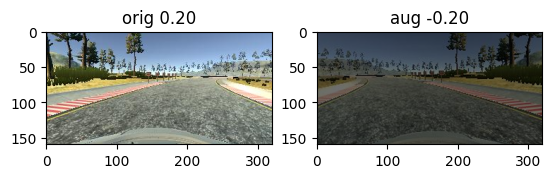

In [3]:
import cv2
import matplotlib.pyplot as plt
from augmentations import random_augment

print(train_df.columns.tolist())  # must include 'center'

row = train_df.iloc[0]
path = row["center"]              # quotes required
print(path)

img_bgr = cv2.imread(path)
if img_bgr is None:
    raise FileNotFoundError(path)

img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img2, steer2 = random_augment(img, float(row["steering"]))

plt.subplot(1, 2, 1); plt.imshow(img); plt.title(f"orig {row['steering']:.2f}")
plt.subplot(1, 2, 2); plt.imshow(img2); plt.title(f"aug {steer2:.2f}")
plt.show()

### Testing PreProcessing

input: (160, 320, 3) output: (66, 200, 3) dtype: float64
min/max: 0.09411764705882353 0.996078431372549


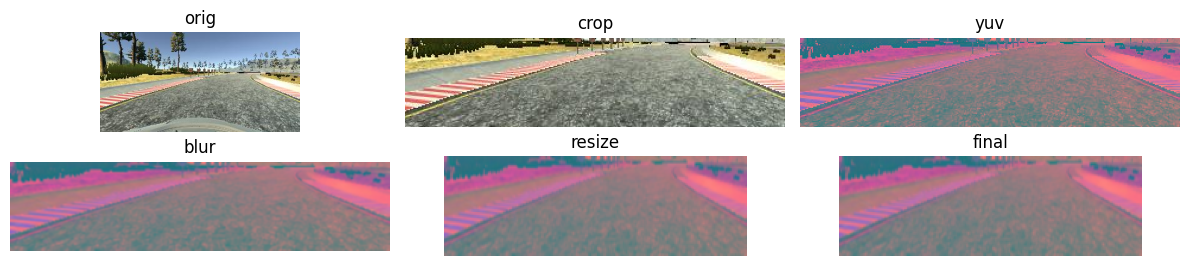

In [4]:
import cv2
import matplotlib.pyplot as plt
from preprocess import preprocess, crop, to_yuv, blur, resize, normalize

row = train_df.iloc[0]
path = row["center"]

img_bgr = cv2.imread(path)
if img_bgr is None:
    raise FileNotFoundError(path)

img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
out = preprocess(img)

print("input:", img.shape, "output:", out.shape, "dtype:", out.dtype)
print("min/max:", out.min(), out.max())  # expect ~0..1 and (66, 200, 3)

# Step-by-step (skip full normalize for display — YUV looks odd but that's OK)
steps = [
    ("orig", img),
    ("crop", crop(img)),
    ("yuv", to_yuv(crop(img))),
    ("blur", blur(to_yuv(crop(img)))),
    ("resize", resize(blur(to_yuv(crop(img))))),
    ("final", out),  # normalized; imshow still works with [0,1]
]

plt.figure(figsize=(12, 4))
for i, (title, im) in enumerate(steps, 1):
    plt.subplot(3, 3, i)
    plt.imshow(im)
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
plt.show()

# float YUV [0,1] -> uint8 for cv2; convert YUV->BGR so the window looks normal
out_u8 = np.clip(out * 255, 0, 255).astype(np.uint8)
out_bgr = cv2.cvtColor(out_u8, cv2.COLOR_YUV2BGR)
out_view = cv2.resize(out_bgr, (400, 132), interpolation=cv2.INTER_NEAREST)
# cv2.imshow("original", img_bgr)
# cv2.imshow("final", out_view)
# cv2.waitKey(0)          # press any key to close
# cv2.destroyAllWindows()


# Apply Augments

### Check for rows with missing images

In [10]:
import cv2
bad = []
for path in train_df["center"]:
    if cv2.imread(str(path).strip()) is None:
        bad.append(path)
print(len(bad), "bad")
print(bad[:10])

10 bad
['D:\\DPS 920\\DPS920_final_project\\IMG\\center_2026_08_01_19_47_04_347.jpg', 'D:\\DPS 920\\DPS920_final_project\\IMG\\center_2026_08_01_19_47_05_692.jpg', 'D:\\DPS 920\\DPS920_final_project\\IMG\\center_2026_08_01_19_47_03_861.jpg', 'D:\\DPS 920\\DPS920_final_project\\IMG\\center_2026_08_01_19_47_04_487.jpg', 'D:\\DPS 920\\DPS920_final_project\\IMG\\center_2026_08_01_19_47_03_997.jpg', 'D:\\DPS 920\\DPS920_final_project\\IMG\\center_2026_08_01_19_47_03_929.jpg', 'D:\\DPS 920\\DPS920_final_project\\IMG\\center_2026_08_01_19_47_04_419.jpg', 'D:\\DPS 920\\DPS920_final_project\\IMG\\center_2026_08_01_19_47_04_764.jpg', 'D:\\DPS 920\\DPS920_final_project\\IMG\\center_2026_08_01_19_47_04_130.jpg', 'D:\\DPS 920\\DPS920_final_project\\IMG\\center_2026_08_01_19_47_05_469.jpg']


In [12]:
import cv2
bad = []
for path in val_df["center"]:
    if cv2.imread(str(path).strip()) is None:
        bad.append(path)
print(len(bad), "bad")
print(bad[:10])

0 bad
[]


In [11]:
ok = train_df["center"].apply(lambda p: cv2.imread(str(p).strip()) is not None)
train_df = train_df[ok].reset_index(drop=True)
# same for val_df, then rebuild train_gen / val_gen

ok = val_df["center"].apply(lambda p: cv2.imread(str(p).strip()) is not None)
val_df = val_df[ok].reset_index(drop=True)

In [13]:
import cv2
import numpy as np
from tensorflow.keras.utils import Sequence
from preprocess import preprocess
from augmentations import random_augment

class DataGenerator(Sequence):
    def __init__(self, df, batch_size=32, training=True):
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.training = training
        self.indices = np.arange(len(self.df))

    def __len__(self):
        return len(self.df) // self.batch_size

    def __getitem__(self, index):
        batch_idx = self.indices[
            index * self.batch_size : (index + 1) * self.batch_size
        ]
        batch = self.df.iloc[batch_idx]

        images = []
        steers = []

        for _, row in batch.iterrows():
            steering = float(row["steering"])
            # randomly pick a camera only for training, else use center cam
            if self.training:
                cam = np.random.choice(["center", "left", "right"])
                if cam == "left":
                    steering += 0.2
                elif cam == "right":
                    steering -= 0.2
            else:
                cam = "center"

            # get image
            path = str(row[cam]).strip()
            img = cv2.imread(path)
            if img is None:
                print("Cannot load:", path)
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            if self.training:
                img, steering = random_augment(img, steering)

            img = preprocess(img)
            images.append(img)
            steers.append(steering)

        return (
            np.array(images, dtype=np.float32),
            np.array(steers, dtype=np.float32),
        )

    def on_epoch_end(self):
        # new order each epoch; augments also re-roll in __getitem__
        if self.training:
            np.random.shuffle(self.indices)


train_gen = DataGenerator(train_df, batch_size=32, training=True)
val_gen = DataGenerator(val_df, batch_size=32, training=False)

print(len(train_gen), "train batches,", len(val_gen), "val batches")

75 train batches, 18 val batches


# Training

Epoch 1/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.0444

75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - loss: 0.0431 - val_loss: 0.0151
Epoch 2/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 0.0413 - val_loss: 0.0168
Epoch 3/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0348

75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0314 - val_loss: 0.0112
Epoch 4/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0269

75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - loss: 0.0257 - val_loss: 0.0081
Epoch 5/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0245 - val_loss: 0.0120
Epoch 6/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - loss: 0.0231 - val_loss: 0.0099
Epoch 7/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - loss: 0.0231 - val_loss: 0.0096
Epoch 8/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0228

75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - loss: 0.0218 - val_loss: 0.0081
Epoch 9/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - loss: 0.0214 - val_loss: 0.0109
Epoch 10/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - loss: 0.0205 - val_loss: 0.0124
Epoch 11/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - loss: 0.0199 - val_loss: 0.0095
Epoch 12/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - loss: 0.0188 - val_loss: 0.0082
Epoch 13/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0196

75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - loss: 0.0190 - val_loss: 0.0064
Epoch 14/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - loss: 0.0190 - val_loss: 0.0071
Epoch 15/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - loss: 0.0171 - val_loss: 0.0088
Epoch 16/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0174 - val_loss: 0.0107
Epoch 17/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - loss: 0.0170 - val_loss: 0.0076
Epoch 18/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 0.0166 - val_loss: 0.0082


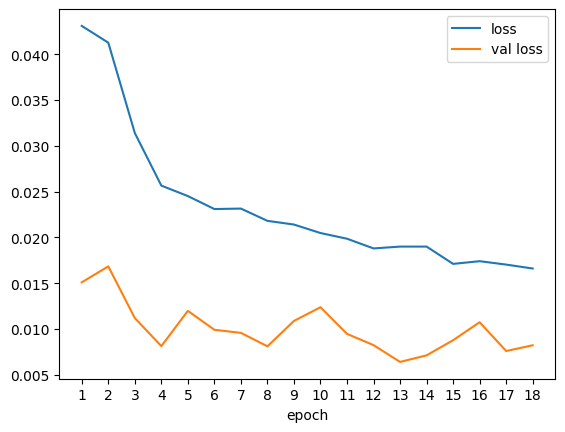

In [15]:
from keras import Sequential, layers
from keras.optimizers import Adam
from keras.models import save_model
from keras.callbacks import EarlyStopping, ModelCheckpoint


# MODEL TRAINING
# Bojarski, M., Del Testa, D., Dworakowski, D., Firner, B., Flepp, B., Goyal, P., Jackel, L. D., Monfort, M., Muller, U., Zhang, J., Zhang, X., Zhao, J., & Zieba, K. 
# (2016, April 25). End to end learning for self-driving cars. arXiv.org. 
# https://arxiv.org/abs/1604.07316 
model = Sequential([
    # Bojarski, M et. al recommends strides of 2x2
    layers.Conv2D(24, (5, 5), strides=(2, 2), activation="relu", input_shape=(66, 200, 3)),
    layers.Conv2D(36, (5, 5), strides=(2, 2), activation="relu"),
    layers.Conv2D(48, (5, 5), strides=(2, 2), activation="relu"),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.Flatten(),
    layers.Dense(100, activation="relu"),
    layers.Dense(50, activation="relu"),
    layers.Dense(10, activation="relu"),
    # regression: 1 output (steering)
    # classification: layers.Dense(num_classes, activation="softmax")
    layers.Dense(1),  # resulting steering angle
])

# MAE is more robust to outliers than MSE
# MAE is not differentiable
# MSE is sensitive to outliers
# Huber Loss
# Log-Cosh Loss

# stochastic G descent: drunk man going down hill.
# stochastic G descent: batch up the data, update all weights once, move onto next batch
# at the end you end up at SOME local minimum


# Early stopping keeps track of val_loss; if it doesn't improve for 5 epochs, it stops training, and restores the best weights
# good for avoiding overfitting
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,              # stop if val_loss doesn't improve for 5 epochs
        restore_best_weights=True,
    ),
# saves the model with the best weights to disk during training 
    ModelCheckpoint(
        "model.h5",
        monitor="val_loss",
        save_best_only=True,
    ),
]


model.compile(optimizer=Adam(learning_rate=1e-4), loss="mse")
# change batching
# H = model.fit(X, y, validation_data=(X_val, y_val), epochs=12, batch_size=32)
H = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks
)

# EVALUATE
epochs = range(1, len(H.history["loss"]) + 1)

plt.plot(epochs, H.history["loss"], label="loss")
plt.plot(epochs, H.history["val_loss"], label="val loss")
plt.xticks(epochs)          # tick every 1 epoch
plt.xlabel("epoch")
plt.legend()
plt.show()

# save_model(model, "model.h5")